# Dhaka Deep Dive — Neighborhood-Level Local Decision Support

The national/division-level view (`eda_v2.ipynb`, and the v1 report) already
establishes Dhaka as the strongest market. This notebook goes one level
deeper: within Dhaka, which *neighborhoods* actually have enough data to
compare, and how different are they from each other and from the Dhaka-wide
average?

This is the direct-analysis version of what was originally scoped as a
"local decision-support module" — same output, done here instead of as
pre-built reusable infrastructure, since only a handful of Dhaka
neighborhoods have enough listing density to support this kind of drill-down
today.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

listings = pd.read_csv("../final_data/listings.csv")
hosts = pd.read_csv("../final_data/hosts.csv")
facilities = pd.read_csv("../final_data/facilities.csv")
reviews = pd.read_csv("../data/processed/reviews.csv", parse_dates=["review_date"])

for col in ["bedrooms", "beds", "baths", "listing_rating"]:
    listings[col] = pd.to_numeric(listings[col], errors="coerce")

fac_cols = [c for c in facilities.columns if c not in ("base_urls", "facilities")]

## 1. Why Dhaka (recap)

From the national EDA: Dhaka has the deepest listing base, the most review
volume, and — unlike most other divisions — enough price/rating coverage to
trust the numbers. It's the only division where a neighborhood-level
drill-down is actually supportable by the data.

In [2]:
VALID_BD_DIVISIONS = [
    "Dhaka Division", "Chittagong", "Sylhet Division", "Rajshahi Division",
    "Barisal Division", "Khulna Division", "Rangpur Division", "Mymensingh Division",
]
bd = listings[listings["principalSubdivision"].isin(VALID_BD_DIVISIONS)]
div_summary = bd.groupby("principalSubdivision").agg(
    listings=("base_urls", "size"),
    price_known=("price_per_night", "count"),
    avg_price=("price_per_night", "mean"),
).round(2).sort_values("listings", ascending=False)
div_summary

,listings,price_known,avg_price
principalSubdivision,,,
Dhaka Division,656,461,40.88
Chittagong,318,275,67.12
Sylhet Division,158,6,36.00
Rajshahi Division,67,5,33.00
Barisal Division,52,2,121.00
Khulna Division,52,16,57.31
Rangpur Division,24,4,38.00
Mymensingh Division,21,0,NaN


In [3]:
dhaka = listings[listings["principalSubdivision"] == "Dhaka Division"].copy()
print(f"Dhaka: {len(dhaka)} listings ({len(dhaka)/len(bd)*100:.0f}% of all BD-division listings)")

Dhaka: 656 listings (49% of all BD-division listings)


## 2. Neighborhood landscape within Dhaka

`localityName` is 100% populated, but density varies enormously — most
neighborhoods have only 1-3 listings, far too thin to say anything reliable.
Showing the full picture here so the drill-down choices below are
transparent, not cherry-picked.

In [4]:
locality_summary = dhaka.groupby("localityName").agg(
    listings=("base_urls", "size"),
    price_known=("price_per_night", "count"),
    avg_price=("price_per_night", "mean"),
    rating_known=("listing_rating", "count"),
    avg_rating=("listing_rating", "mean"),
).round(2).sort_values("listings", ascending=False)
locality_summary

,listings,price_known,avg_price,rating_known,avg_rating
localityName,,,,,
Gulshan,120,82,53.05,75,4.82
Mohammadpur,52,44,28.73,20,4.85
Dhanmondi,47,30,50.77,26,4.74
Bashundhara Residential Area,47,36,42.03,20,4.73
Uttara,46,30,33.23,19,4.80
...,...,...,...,...,...
Bishil,1,1,10.00,1,5.00
Narayanganj,1,0,NaN,0,NaN
Naria,1,0,NaN,0,NaN


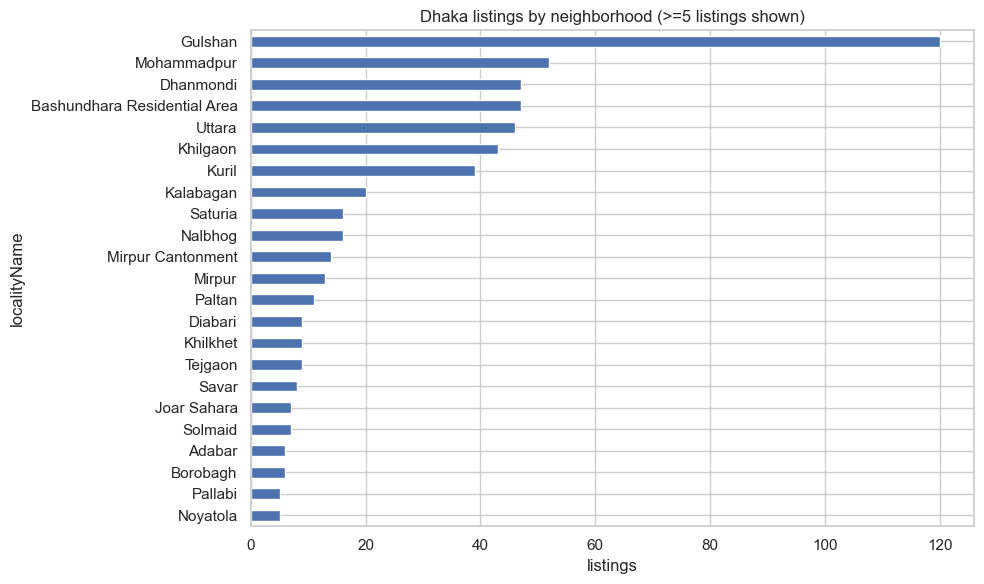

Neighborhoods with <5 listings: 64 (101 listings total) — too thin to analyze individually.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
top_localities = locality_summary[locality_summary["listings"] >= 5]
top_localities["listings"].sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Dhaka listings by neighborhood (>=5 listings shown)")
ax.set_xlabel("listings")
plt.tight_layout()
plt.show()

print(f"Neighborhoods with <5 listings: {(locality_summary['listings'] < 5).sum()} "
      f"({locality_summary[locality_summary['listings'] < 5]['listings'].sum()} listings total) — too thin to analyze individually.")

## 3. Deep-dive comparison: the 8 neighborhoods with real density

`Dhaka` (generic, catch-all locality) is excluded here — it's what's left
after a targeted Nominatim/OpenStreetMap reverse-geocoding backfill (run
separately, see `src/airbnb_pipeline/stages/geocode_backfill.py`) resolved
95% of Dhaka's listings to a real neighborhood name; the remainder is a
residual, not an actual named area. The 8 named neighborhoods with >=20
listings and decent price/rating coverage: **Gulshan, Mohammadpur,
Dhanmondi, Bashundhara Residential Area, Uttara, Khilgaon, Kuril,
Kalabagan** — including Uttara and Bashundhara, which the backfill newly
unlocked and which the v1 report specifically named as demand areas
(airport-linked and residential/institutional respectively) that couldn't
be analyzed before this fix.

For each: comparable-set size, pricing, rating, host professionalization
(share of listings run by a multi-listing operator vs. an individual host),
top amenities, and recent review velocity (demand signal, from the
reviews table — coverage caveat: only ~33% of listings nationally have
review-level detail, so treat this as directional, not exhaustive).

In [6]:
DENSE_NEIGHBORHOODS = ["Gulshan", "Mohammadpur", "Dhanmondi", "Bashundhara Residential Area", "Uttara", "Khilgaon", "Kuril", "Kalabagan"]


def profile_area(area_df, label):
    area_df = area_df.merge(hosts, on="host_link", how="left")
    area_df = area_df.merge(facilities[["base_urls"] + fac_cols], on="base_urls", how="left")

    area_reviews = reviews[reviews["base_urls"].isin(area_df["base_urls"])]
    monthly_velocity = area_reviews.set_index("review_date").resample("MS").size().tail(6).mean()

    multi_listing_share = (area_df["host_link"].map(area_df["host_link"].value_counts()) > 1).mean()
    top_amenities = (area_df[fac_cols].mean() * 100).sort_values(ascending=False).head(5)

    return {
        "area": label,
        "listings": len(area_df),
        "avg_price": round(area_df["price_per_night"].mean(), 2),
        "median_price": round(area_df["price_per_night"].median(), 2),
        "price_known": int(area_df["price_per_night"].notna().sum()),
        "avg_rating": round(area_df["listing_rating"].mean(), 2),
        "rating_known": int(area_df["listing_rating"].notna().sum()),
        "avg_host_response_rate": round(area_df["host_response_rate"].mean(), 1),
        "multi_listing_host_share_pct": round(multi_listing_share * 100, 1),
        "monthly_review_velocity_recent": round(monthly_velocity, 1),
        "top_amenities": top_amenities,
    }


profiles = [profile_area(dhaka[dhaka["localityName"] == nb].copy(), nb) for nb in DENSE_NEIGHBORHOODS]
profiles_df = pd.DataFrame(profiles).set_index("area")

comparison_cols = ["listings", "avg_price", "median_price", "price_known", "avg_rating",
                    "rating_known", "avg_host_response_rate", "multi_listing_host_share_pct",
                    "monthly_review_velocity_recent"]
profiles_df[comparison_cols]

,listings,avg_price,median_price,price_known,avg_rating,rating_known,avg_host_response_rate,multi_listing_host_share_pct,monthly_review_velocity_recent
area,,,,,,,,,
Gulshan,120,53.05,44.0,82,4.82,75,95.7,60.8,44.7
Mohammadpur,52,28.73,25.5,44,4.85,20,94.7,73.1,8.8
Dhanmondi,47,50.77,42.0,30,4.74,26,98.4,46.8,16.3
Bashundhara Residential Area,47,42.03,39.0,36,4.73,20,97.5,31.9,10.7
Uttara,46,33.23,28.0,30,4.80,19,95.2,41.3,11.5
Khilgaon,43,27.11,21.0,35,4.82,10,92.1,41.9,4.0
Kuril,39,33.89,32.0,35,4.41,17,98.4,74.4,9.8
Kalabagan,20,43.29,42.5,14,4.73,10,92.6,20.0,2.7


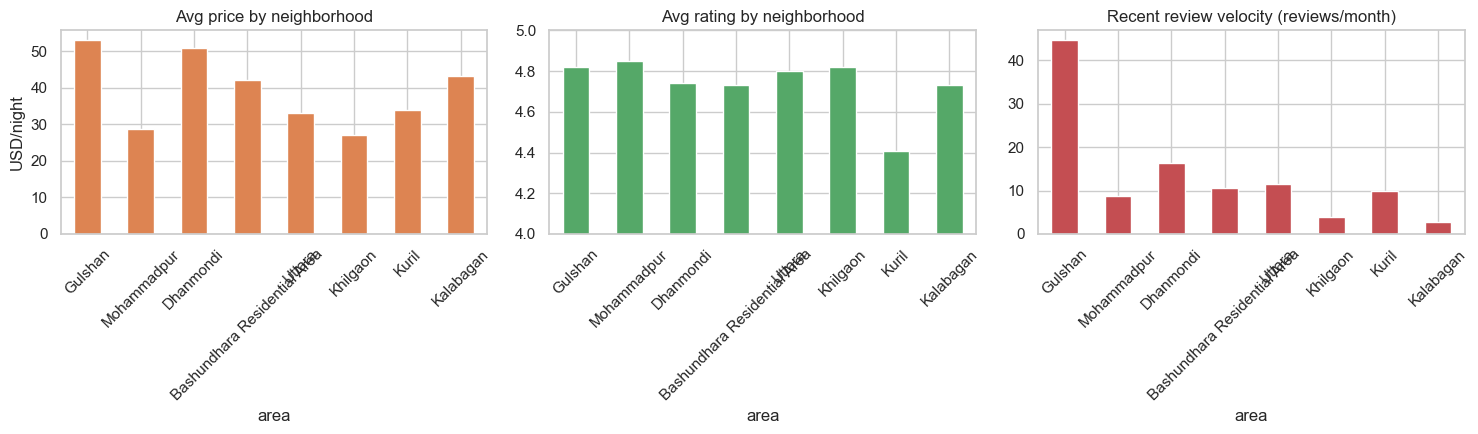

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

profiles_df["avg_price"].plot.bar(ax=axes[0], color="#DD8452")
axes[0].set_title("Avg price by neighborhood")
axes[0].set_ylabel("USD/night")

profiles_df["avg_rating"].plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Avg rating by neighborhood")
axes[1].set_ylim(4, 5)

profiles_df["monthly_review_velocity_recent"].plot.bar(ax=axes[2], color="#C44E52")
axes[2].set_title("Recent review velocity (reviews/month)")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [8]:
top_price = profiles_df["avg_price"].idxmax()
top_velocity = profiles_df["monthly_review_velocity_recent"].idxmax()
velocity_ratio = profiles_df["monthly_review_velocity_recent"].max() / profiles_df["monthly_review_velocity_recent"].min()

print(f"Highest avg price: {top_price} (${profiles_df.loc[top_price, 'avg_price']})")
print(f"Highest review velocity: {top_velocity} ({profiles_df.loc[top_velocity, 'monthly_review_velocity_recent']}/month)")
print(f"Velocity spread across the {len(profiles_df)} neighborhoods: {velocity_ratio:.1f}x "
      f"(min {profiles_df['monthly_review_velocity_recent'].min()}, max {profiles_df['monthly_review_velocity_recent'].max()})")
print()
print("Price vs. velocity rank (a neighborhood priced high but ranked low on velocity is a caution flag):")
comparison = profiles_df[["avg_price", "monthly_review_velocity_recent"]].copy()
comparison["price_rank"] = comparison["avg_price"].rank(ascending=False).astype(int)
comparison["velocity_rank"] = comparison["monthly_review_velocity_recent"].rank(ascending=False).astype(int)
comparison.sort_values("price_rank")

Highest avg price: Gulshan ($53.05)
Highest review velocity: Gulshan (44.7/month)
Velocity spread across the 8 neighborhoods: 16.6x (min 2.7, max 44.7)

Price vs. velocity rank (a neighborhood priced high but ranked low on velocity is a caution flag):


,avg_price,monthly_review_velocity_recent,price_rank,velocity_rank
area,,,,
Gulshan,53.05,44.7,1,1
Dhanmondi,50.77,16.3,2,2
Kalabagan,43.29,2.7,3,8
Bashundhara Residential Area,42.03,10.7,4,4
Kuril,33.89,9.8,5,5
Uttara,33.23,11.5,6,3
Mohammadpur,28.73,8.8,7,6
Khilgaon,27.11,4.0,8,7


**What to take from this**: whichever neighborhood tops both price *and*
velocity (see above) is the clearest case — high price backed by real demand,
not just a pricing outlier. Any neighborhood with a much better price rank
than velocity rank is a caution flag: it looks attractive on paper but has
comparatively thin evidence of actual bookings, a distinction division-level
analysis alone would completely miss.

In [9]:
for area, row in profiles_df.iterrows():
    print(f"{area}: " + ", ".join(f"{k} ({v:.0f}%)" for k, v in row["top_amenities"].items()))

Gulshan: wifi (98%), washer (72%), fire extinguisher (68%), refrigerator (68%), free parking (66%)
Mohammadpur: wifi (100%), refrigerator (71%), washer (67%), fire extinguisher (60%), clothing storage (58%)
Dhanmondi: wifi (98%), air conditioning (72%), washer (72%), free parking (68%), fire extinguisher (62%)
Bashundhara Residential Area: wifi (98%), air conditioning (81%), free parking (79%), fire extinguisher (66%), washer (64%)
Uttara: wifi (98%), air conditioning (70%), refrigerator (67%), security cameras (59%), washer (59%)
Khilgaon: wifi (93%), fire extinguisher (70%), air conditioning (70%), free parking (53%), washer (49%)
Kuril: wifi (100%), fire extinguisher (87%), paid parking (85%), exercise equipment (85%), pool (82%)
Kalabagan: wifi (100%), air conditioning (70%), free parking (65%), washer (65%), refrigerator (50%)


## 4. Viability estimate per neighborhood

Same framework the v1 report already uses — this project doesn't have
booking/occupancy data, so occupancy assumptions come from the external
secondary-research benchmark it cites for Dhaka (~42% median occupancy), run
as three scenarios. Revenue is estimated from each neighborhood's own median
comparable price, not a flat citywide number.

**This is an estimate for screening, not a forecast** — same caveat the v1
report already states.

In [10]:
OCCUPANCY_SCENARIOS = {"Stress": 0.25, "Base (external Dhaka benchmark)": 0.42, "Strong": 0.55}
SELF_MANAGED_COST_RATIO = (0.30, 0.45)
MANAGED_COST_RATIO = (0.45, 0.65)

rows = []
for area, row in profiles_df.iterrows():
    price = row["median_price"]
    if pd.isna(price):
        continue
    for scenario, occ in OCCUPANCY_SCENARIOS.items():
        gross = price * 365 * occ
        rows.append({
            "area": area,
            "scenario": scenario,
            "gross_revenue_usd": round(gross),
            "net_self_managed_usd": f"{gross*(1-SELF_MANAGED_COST_RATIO[1]):,.0f}-{gross*(1-SELF_MANAGED_COST_RATIO[0]):,.0f}",
            "net_managed_usd": f"{gross*(1-MANAGED_COST_RATIO[1]):,.0f}-{gross*(1-MANAGED_COST_RATIO[0]):,.0f}",
        })

viability = pd.DataFrame(rows).set_index(["area", "scenario"])
viability

gross_revenue_usd  \
area                         scenario                                             
Gulshan                      Stress                                        4015   
                             Base (external Dhaka benchmark)               6745   
                             Strong                                        8833   
Mohammadpur                  Stress                                        2327   
                             Base (external Dhaka benchmark)               3909   
                             Strong                                        5119   
Dhanmondi                    Stress                                        3832   
                             Base (external Dhaka benchmark)               6439   
                             Strong                                        8432   
Bashundhara Residential Area Stress                                        3559   
                             Base (external Dhaka benchmark)               5979   
                             Strong                                        7829   
Uttara                       Stress                                        2555   
                             Base (external Dhaka benchmark)               4292   
                             Strong                                        5621   
Khilgaon                     Stress                                        1916   
                             Base (external Dhaka benchmark)               3219   
                             Strong                                        4216   
Kuril                        Stress                                        2920   
                             Base (external Dhaka benchmark)               4906   
                             Strong                                        6424   
Kalabagan                    Stress                                        3878   
                             Base (external Dhaka benchmark)               6515   
                             Strong                                        8532   

                                                             net_self_managed_usd  \
area                         scenario                                               
Gulshan                      Stress                                   2,208-2,810   
                             Base (external Dhaka benchmark)          3,710-4,722   
                             Strong                                   4,858-6,183   
Mohammadpur                  Stress                                   1,280-1,629   
                             Base (external Dhaka benchmark)          2,150-2,736   
                             Strong                                   2,816-3,583   
Dhanmondi                    Stress                                   2,108-2,683   
                             Base (external Dhaka benchmark)          3,541-4,507   
                             Strong                                   4,637-5,902   
Bashundhara Residential Area Stress                                   1,957-2,491   
                             Base (external Dhaka benchmark)          3,288-4,185   
                             Strong                                   4,306-5,480   
Uttara                       Stress                                   1,405-1,788   
                             Base (external Dhaka benchmark)          2,361-3,005   
                             Strong                                   3,092-3,935   
Khilgaon                     Stress                                   1,054-1,341   
                             Base (external Dhaka benchmark)          1,771-2,254   
                             Strong                                   2,319-2,951   
Kuril                        Stress                                   1,606-2,044   
                             Base (external Dhaka benchmark)          2,698-3,434   
                             Stro

In [11]:
generic_bucket = (dhaka["localityName"] == "Dhaka").sum()
thin_localities = locality_summary[locality_summary["listings"] < 5]["listings"].sum()
too_thin_total = generic_bucket + thin_localities
print(f"Generic 'Dhaka' geocoding bucket: {generic_bucket} listings")
print(f"Named neighborhoods with <5 listings each: {thin_localities} listings across {(locality_summary['listings'] < 5).sum()} localities")
print(f"Combined: {too_thin_total}/{len(dhaka)} ({too_thin_total/len(dhaka)*100:.0f}%) too thin/unresolved to profile individually")

Generic 'Dhaka' geocoding bucket: 0 listings
Named neighborhoods with <5 listings each: 101 listings across 64 localities
Combined: 101/656 (15%) too thin/unresolved to profile individually


## Summary

- Dhaka-wide averages hide real variation between neighborhoods — see the
  price/rating/velocity comparison and the price-vs-velocity rank table
  above for the specific current leaders and any caution-flag cases (high
  price rank, low velocity rank).
- A locality-resolution backfill (Nominatim/OpenStreetMap, run separately)
  took Dhaka from 43% unresolved down to ~5% unresolved, which is what
  unlocked Uttara and Bashundhara Residential Area as analyzable
  neighborhoods here — both specifically named in the v1 report as demand
  areas (airport-linked and residential/institutional) that couldn't be
  profiled before this fix.
- The generic "Dhaka" geocoding bucket and named neighborhoods with <5
  listings each (counts above) remain too thin to profile individually —
  any client asking about one of those specifically would need targeted
  validation beyond what this dataset supports.
- Across all divisions, ~19% of listings are still unresolved to a specific
  locality (worse outside Dhaka — Sylhet, Barisal, Rangpur, Mymensingh have
  the largest remaining gaps); the unresolved rows have been exported to
  `final_data/unresolved_localities.csv` for manual review.